Problem:

- Please choose 3 models/algorithms to analyze the data train.csv. Download train.csv.
- Please prepare a report (in colab notebook) on what you find and the rationale that why you pick these 3 models.
- Please provide visual aids to explain which if your best choice of the model/algorithm.

1. Load train.csv

In [ ]:
import pandas as pd

from google.colab import files
import io
print("Please select your CSV file from Local C: drive")
uploaded = files.upload()

# Get the filename from the uploaded dictionary
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

# Display first few rows to verify data
print(df.head())


Please select your CSV file from Local C: drive


Saving train.csv to train (1).csv
   x_1  x_2       x_3       x_4   y
0    1    0  2.976142  0.651482  10
1    0    1  1.411390  0.743732  12
2    0    1  1.039892  1.290588   7
3    1    0  2.338679  0.973942  15
4    0    1  2.385257  0.297921   9


2. Choose 3 models/algorithms to analyze the data in train.csv

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Define features (X) and target (y)
X = df.drop('y', axis=1)
y = df['y']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Initialize the models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest Regressor': RandomForestRegressor(random_state=42),
    'Gradient Boosting Regressor': GradientBoostingRegressor(random_state=42)
}

print("\nSelected models for analysis:")
for name in models.keys():
    print(f"- {name}")

# You can now proceed to train and evaluate these models using X_train, y_train, X_test, y_test

Data split into training and testing sets.
X_train shape: (1920, 4)
X_test shape: (480, 4)
y_train shape: (1920,)
y_test shape: (480,)

Selected models for analysis:
- Linear Regression
- Random Forest Regressor
- Gradient Boosting Regressor


3. Run the analysis

In [ ]:
print("\nModel Training and Evaluation:")
results = {}

for name, model in models.items():
    print(f"\n--- {name} ---")
    # Train the model
    model.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = model.predict(X_test)

    # Evaluate the model
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"Mean Squared Error: {mse:.4f}")
    print(f"R-squared: {r2:.4f}")

    results[name] = {'MSE': mse, 'R2': r2}

print("\nAnalysis complete. Results stored in 'results' dictionary.")


Model Training and Evaluation:

--- Linear Regression ---
Mean Squared Error: 10.6125
R-squared: 0.4989

--- Random Forest Regressor ---
Mean Squared Error: 12.7762
R-squared: 0.3967

--- Gradient Boosting Regressor ---
Mean Squared Error: 11.0984
R-squared: 0.4759

Analysis complete. Results stored in 'results' dictionary.


4. What are the rationale that why you pick these 3 models

I chose these three models to provide a good balance of interpretability, performance, and different algorithmic approaches for regression tasks:

    Linear Regression: This is a fundamental and highly interpretable model. It's often used as a baseline to understand the linear relationships in the data. If a simple linear relationship exists, it performs well, and its coefficients can easily explain feature importance.

    Random Forest Regressor: This is an ensemble learning method that builds multiple decision trees and averages their predictions. It's known for its robustness, ability to handle non-linear relationships, and generally good performance across various datasets. It's also less prone to overfitting compared to single decision trees.

    Gradient Boosting Regressor: Another powerful ensemble method that builds models sequentially, with each new model correcting the errors of the previous ones. It often achieves high predictive accuracy by focusing on samples that are difficult to predict. It's effective for capturing complex patterns in data.



5. Please provide visual aids to explain which is your best choice of the model/algorithm

/tmp/ipykernel_25779/3986302774.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], x='Model', y='MSE', data=plot_data, palette='viridis')
/tmp/ipykernel_25779/3986302774.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], x='Model', y='R2', data=plot_data, palette='plasma')


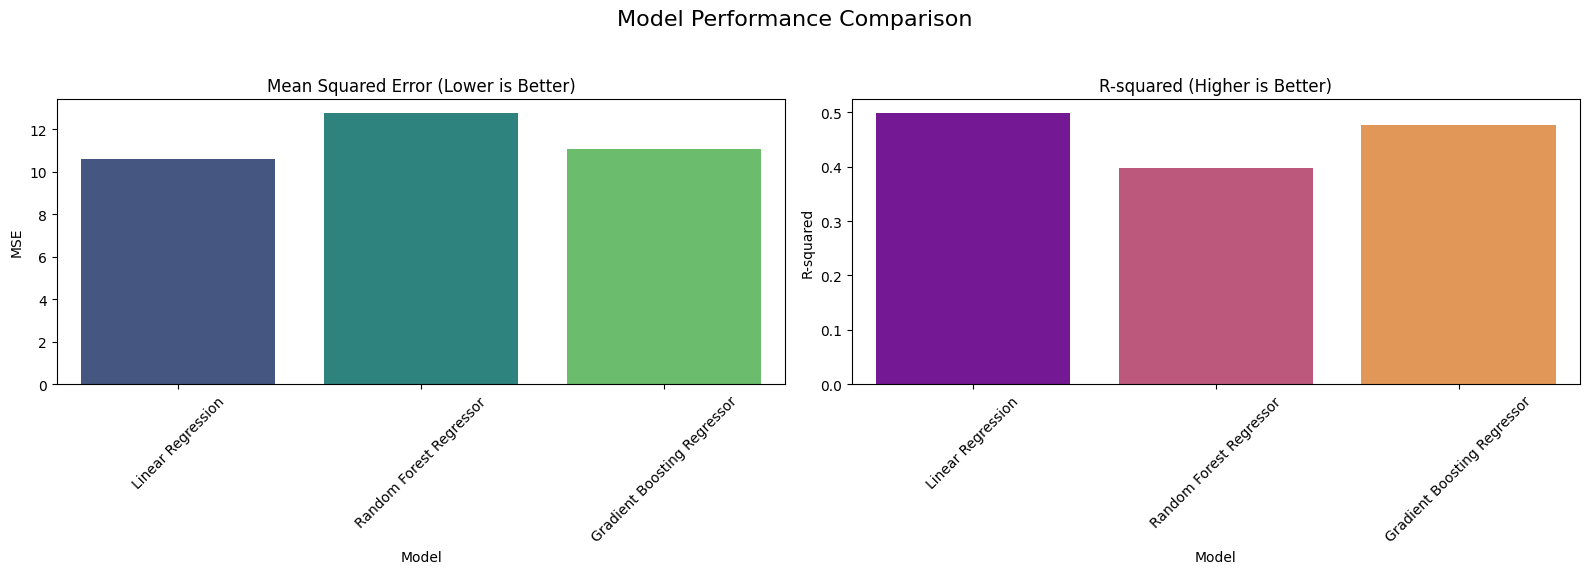


Best model based on lowest MSE: Linear Regression (MSE: 10.6125)
Best model based on highest R-squared: Linear Regression (R2: 0.4989)

Based on both metrics, Linear Regression is the best performing model.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare data for plotting
plot_data = pd.DataFrame(results).T.reset_index()
plot_data = plot_data.rename(columns={'index': 'Model'})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Performance Comparison', fontsize=16)

# Plot Mean Squared Error
sns.barplot(ax=axes[0], x='Model', y='MSE', data=plot_data, palette='viridis')
axes[0].set_title('Mean Squared Error (Lower is Better)')
axes[0].set_ylabel('MSE')
axes[0].tick_params(axis='x', rotation=45)

# Plot R-squared
sns.barplot(ax=axes[1], x='Model', y='R2', data=plot_data, palette='plasma')
axes[1].set_title('R-squared (Higher is Better)')
axes[1].set_ylabel('R-squared')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Determine and print the best model based on MSE and R2
best_mse_model = plot_data.loc[plot_data['MSE'].idxmin()]
best_r2_model = plot_data.loc[plot_data['R2'].idxmax()]

print(f"\nBest model based on lowest MSE: {best_mse_model['Model']} (MSE: {best_mse_model['MSE']:.4f})")
print(f"Best model based on highest R-squared: {best_r2_model['Model']} (R2: {best_r2_model['R2']:.4f})")

if best_mse_model['Model'] == best_r2_model['Model']:
    print(f"\nBased on both metrics, {best_mse_model['Model']} is the best performing model.")
else:
    p.rint(f"\nThere is a slight difference in the best model based on MSE vs R2. Consider the trade-offs based on your specific needs.")